In [5]:
import numpy as np
import pandas as pd

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, accuracy_score, f1_score


# ----------------------------
# Utilities
# ----------------------------
G = 9.81
TWO_PI = 2 * np.pi


def hs_from_energy(E):
    """Convert energy proxy E* to Hs, enforcing non-negativity."""
    return np.sqrt(np.clip(E, 0.0, None))


def sea_state_class(Hs, bins=None, labels=None):
    """
    Simple sea-state binning. Will be replace with actual operational thresholds.
    """
    if bins is None:
        bins = [0, 0.5, 1.25, 2.5, 4.0, 6.0, 9.0, np.inf]
    if labels is None:
        labels = list(range(len(bins) - 1))
    return pd.cut(Hs, bins=bins, labels=labels, right=False, include_lowest=True)


def add_cyclical_month_features(df):
    """Month-of-year cyclic encoding (global model seasonal features)."""
    m = df.index.month.astype(float)
    df["month_sin"] = np.sin(TWO_PI * (m / 12.0))
    df["month_cos"] = np.cos(TWO_PI * (m / 12.0))
    return df


def add_cyclical_doy_features(df):
    """Day-of-year cyclic encoding (optional, helps finer seasonality)."""
    doy = df.index.dayofyear.astype(float)
    df["doy_sin"] = np.sin(TWO_PI * (doy / 365.25))
    df["doy_cos"] = np.cos(TWO_PI * (doy / 365.25))
    return df


def prepare_features(df_raw: pd.DataFrame) -> pd.DataFrame:
    """
    Build physics-informed features from your cleaned station dataframe.
    Expects columns (at least):
      WVHT, DPD, WSPD, WDIR (optional but recommended), MWD (optional)
    """
    df = df_raw.copy()

    # Ensure time index
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"])
        df = df.sort_values("datetime").set_index("datetime")
    else:
        df = df.sort_index()

    # Optional: enforce hourly cadence. If your data already is hourly, this is harmless.
    # We keep NaNs rather than interpolate to avoid "future leakage".
    df = df.resample("h").mean()

    # Basic physical sanity (we already did a lot; this is just guardrails)
    if "DPD" in df.columns:
        df.loc[df["DPD"] <= 0, "DPD"] = np.nan
    if "WVHT" in df.columns:
        df.loc[df["WVHT"] < 0, "WVHT"] = np.nan
    if "WSPD" in df.columns:
        df.loc[df["WSPD"] < 0, "WSPD"] = np.nan

    # Energy proxy target basis
    df["E_star"] = df["WVHT"] ** 2

    # Direction encoding (avoid 0/360 discontinuity)

    if "WDIR" in df.columns:
        theta_w = np.deg2rad(df["WDIR"])
        df["wdir_sin"] = np.sin(theta_w)
        df["wdir_cos"] = np.cos(theta_w)
    else:
        df["wdir_sin"] = np.nan
        df["wdir_cos"] = np.nan

    if "MWD" in df.columns:
        theta_m = np.deg2rad(df["MWD"])
        df["mwd_sin"] = np.sin(theta_m)
        df["mwd_cos"] = np.cos(theta_m)
    else:
        df["mwd_sin"] = np.nan
        df["mwd_cos"] = np.nan

    # Wind-wave alignment metric (cos(delta)) in [-1, 1]
    df["align"] = df["wdir_cos"] * df["mwd_cos"] + df["wdir_sin"] * df["mwd_sin"]

    # Deep-water physics features from DPD (dominant period)
    T = df["DPD"]
    df["L_deep"] = (G * (T ** 2)) / TWO_PI                 # wavelength
    df["cp_deep"] = (G * T) / TWO_PI                       # phase speed
    df["wind_stress"] = df["WSPD"] ** 2                    # proxy ~ U^2
    df["wave_age"] = df["cp_deep"] / (df["WSPD"] + 1e-6)   # cp/U
    df["steepness"] = df["WVHT"] / (df["L_deep"] + 1e-6)   # Hs/L

    return df


def make_supervised(df_feat: pd.DataFrame, lead_hours: int, lags: list, add_seasonal: bool) -> pd.DataFrame:
    """
    Create a supervised learning table for predicting E_star at t+lead.
    Includes lagged features.
    """
    df = df_feat.copy()

    if add_seasonal:
        df = add_cyclical_month_features(df)
        df = add_cyclical_doy_features(df)

    base_features = [
        "E_star",
        "WSPD",
        "DPD",
        "wind_stress",
        "wave_age",
        "steepness",
        "align",
        "wdir_sin",
        "wdir_cos",
        # we can add "mwd_sin", "mwd_cos" too, later
    ]

    if add_seasonal:
        base_features += ["month_sin", "month_cos", "doy_sin", "doy_cos"]

    # Lag features
    for lag in lags:
        for col in base_features:
            df[f"{col}_lag{lag}"] = df[col].shift(lag)

    # Target: E_star at t+lead
    df["target_E_star"] = df["E_star"].shift(-lead_hours)

    # Keep month for monthly models
    df["month"] = df.index.month

    # Drop rows where target is missing (end of series)
    df = df.dropna(subset=["target_E_star"])

    return df


def time_split(df_sup: pd.DataFrame, train_end: str, val_end: str):
    """Time-based split: train <= train_end, val (train_end, val_end], test > val_end."""
    train = df_sup.loc[:train_end].copy()
    val = df_sup.loc[train_end:val_end].copy()
    test = df_sup.loc[val_end:].copy()
    # Remove the boundary duplicate point (because loc is inclusive)
    val = val[val.index > pd.to_datetime(train_end)]
    test = test[test.index > pd.to_datetime(val_end)]
    return train, val, test


def fit_hgbr(X, y):
    """Reasonable default model; tune later."""
    model = HistGradientBoostingRegressor(
        loss="squared_error",
        learning_rate=0.05,
        max_depth=6,
        max_iter=400,
        min_samples_leaf=30,
        random_state=42,
    )
    model.fit(X, y)
    return model


from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_energy_predictions(y_true_E, y_pred_E):
    """Report MAE/RMSE in Hs units."""
    hs_true = hs_from_energy(y_true_E)
    hs_pred = hs_from_energy(y_pred_E)

    mae = mean_absolute_error(hs_true, hs_pred)

    # Compatible RMSE: compute MSE then sqrt
    mse = mean_squared_error(hs_true, hs_pred)
    rmse = float(np.sqrt(mse))

    return mae, rmse



def evaluate_classification(hs_true, hs_pred):
    """Sea-state classification metrics (editable thresholds in sea_state_class)."""
    y_true = sea_state_class(hs_true).astype(int)
    y_pred = sea_state_class(hs_pred).astype(int)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return acc, f1


def train_monthly_models(train_df, feature_cols, min_samples=500):
    """
    Train one model per month on train_df.
    If a month has too few samples, returns None for that month.
    """
    models = {}
    for m in range(1, 13):
        sub = train_df[train_df["month"] == m]
        if len(sub) < min_samples:
            models[m] = None
            continue
        X = sub[feature_cols]
        y = sub["target_E_star"]
        models[m] = fit_hgbr(X, y)
    return models


def predict_with_monthly_models(test_df, feature_cols, models_by_month, fallback_model):
    """
    Predict using the month-specific model for each row's month.
    If a month model is missing (None), fall back to global model.
    """
    y_pred = np.empty(len(test_df), dtype=float)

    months = test_df["month"].to_numpy()
    X_all = test_df[feature_cols]

    for m in range(1, 13):
        idx = np.where(months == m)[0]
        if len(idx) == 0:
            continue
        X_m = X_all.iloc[idx]
        model = models_by_month.get(m)
        if model is None:
            y_pred[idx] = fallback_model.predict(X_m)
        else:
            y_pred[idx] = model.predict(X_m)

    return y_pred


# ----------------------------
# Main comparison runner
# ----------------------------
def run_global_vs_monthly(
    parquet_path: str,
    lead_hours: int = 3,
    lags: list = [0, 1, 2, 3, 6, 12],
    train_end: str = "2018-12-31",
    val_end: str = "2020-12-31",
):
    # Load & feature build
    df_raw = pd.read_parquet(parquet_path)
    df_feat = prepare_features(df_raw)

    # Build supervised tables
    sup_global = make_supervised(df_feat, lead_hours=lead_hours, lags=lags, add_seasonal=False)
    sup_seasonal = make_supervised(df_feat, lead_hours=lead_hours, lags=lags, add_seasonal=True)

    # Feature column lists (all lagged columns)
    feature_cols_global = [c for c in sup_global.columns if "_lag" in c]
    feature_cols_seasonal = [c for c in sup_seasonal.columns if "_lag" in c]

    # Time splits
    g_train, g_val, g_test = time_split(sup_global, train_end=train_end, val_end=val_end)
    s_train, s_val, s_test = time_split(sup_seasonal, train_end=train_end, val_end=val_end)

    # ----------------------------
    # Persistence baseline
    # E*(t+lead) ~ E*(t)  (lag0)
    # ----------------------------
    # On the test set, "E_star_lag0" is E_star at time t
    y_true = g_test["target_E_star"].to_numpy()
    y_pred_persist = g_test["E_star_lag0"].to_numpy()
    # Remove rows where persistence input is missing
    mask = ~np.isnan(y_pred_persist)
    mae_p, rmse_p = evaluate_energy_predictions(y_true[mask], y_pred_persist[mask])

    # ----------------------------
    # Global model (no seasonal)
    # ----------------------------
    model_global = fit_hgbr(g_train[feature_cols_global], g_train["target_E_star"])
    y_pred_global = model_global.predict(g_test[feature_cols_global])
    mae_g, rmse_g = evaluate_energy_predictions(y_true, y_pred_global)

    # ----------------------------
    # Global model + seasonal features
    # ----------------------------
    model_seasonal = fit_hgbr(s_train[feature_cols_seasonal], s_train["target_E_star"])
    y_true_s = s_test["target_E_star"].to_numpy()
    y_pred_seasonal = model_seasonal.predict(s_test[feature_cols_seasonal])
    mae_s, rmse_s = evaluate_energy_predictions(y_true_s, y_pred_seasonal)

    # ----------------------------
    # Monthly models (trained on same feature set as seasonal table OR global table)
    # We'll use the seasonal table’s lagged features because it’s richer.
    # Month feature is used only for routing, not fed to the model.
    # ----------------------------
    monthly_models = train_monthly_models(s_train, feature_cols_seasonal, min_samples=500)
    y_pred_monthly = predict_with_monthly_models(
        s_test,
        feature_cols_seasonal,
        models_by_month=monthly_models,
        fallback_model=model_seasonal,  # sensible fallback
    )
    mae_m, rmse_m = evaluate_energy_predictions(y_true_s, y_pred_monthly)

    # Optional: classification metrics
    hs_true = hs_from_energy(y_true_s)
    acc_s, f1_s = evaluate_classification(hs_true, hs_from_energy(y_pred_seasonal))
    acc_m, f1_m = evaluate_classification(hs_true, hs_from_energy(y_pred_monthly))

    results = pd.DataFrame(
        [
            {"model": "persistence", "MAE_Hs": mae_p, "RMSE_Hs": rmse_p, "ACC_seastate": np.nan, "F1_seastate": np.nan},
            {"model": "global", "MAE_Hs": mae_g, "RMSE_Hs": rmse_g, "ACC_seastate": np.nan, "F1_seastate": np.nan},
            {"model": "global+season", "MAE_Hs": mae_s, "RMSE_Hs": rmse_s, "ACC_seastate": acc_s, "F1_seastate": f1_s},
            {"model": "monthly_experts", "MAE_Hs": mae_m, "RMSE_Hs": rmse_m, "ACC_seastate": acc_m, "F1_seastate": f1_m},
        ]
    )

    # Skill relative to persistence (RMSE)
    results["RMSE_skill_vs_persist"] = 1.0 - (results["RMSE_Hs"] / rmse_p)

    return results.sort_values("RMSE_Hs")


In [7]:
import matplotlib.pyplot as plt
import numpy as np

def plot_monthly_hs_box(df_feat):
    hs = df_feat["WVHT"].dropna()
    months = hs.index.month
    data = [hs[months == m].values for m in range(1, 13)]

    plt.figure(figsize=(12, 5))
    plt.boxplot(data, showfliers=False)
    plt.xticks(range(1, 13), ["J","F","M","A","M","J","J","A","S","O","N","D"])
    plt.ylabel("Hs [m]")
    plt.title("Seasonality of Significant Wave Height (Hs) by Month")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()
    
def plot_missingness(df_feat, cols=("WVHT","DPD","WSPD","WDIR","MWD")):
    miss = df_feat[list(cols)].isna().resample("D").mean()

    plt.figure(figsize=(12, 4))
    for c in miss.columns:
        plt.plot(miss.index, miss[c], label=c)
    plt.ylabel("Daily fraction missing")
    plt.title("Missingness Over Time (Daily)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
from sklearn.metrics import mean_squared_error

def plot_validation_curve_hgbr(model, X_val, y_val_E):
    # Convert E* truth to Hs truth
    hs_true = np.sqrt(np.clip(y_val_E.to_numpy(), 0, None))

    rmses = []
    iters = []
    for i, y_pred_E in enumerate(model.staged_predict(X_val)):
        hs_pred = np.sqrt(np.clip(y_pred_E, 0, None))
        rmse = np.sqrt(mean_squared_error(hs_true, hs_pred))
        rmses.append(rmse)
        iters.append(i + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(iters, rmses)
    plt.xlabel("Boosting Iteration")
    plt.ylabel("Validation RMSE in Hs [m]")
    plt.title("Validation RMSE vs Training Iterations")
    plt.grid(True, alpha=0.3)
    plt.show()
    
def plot_forecast_timeseries(test_index, y_true_E, y_pred_E, title, days=14):
    hs_true = np.sqrt(np.clip(y_true_E, 0, None))
    hs_pred = np.sqrt(np.clip(y_pred_E, 0, None))

    # Select last N days for readability
    end = test_index.max()
    start = end - pd.Timedelta(days=days)
    mask = (test_index >= start) & (test_index <= end)

    plt.figure(figsize=(12, 4))
    plt.plot(test_index[mask], hs_true[mask], label="Observed Hs")
    plt.plot(test_index[mask], hs_pred[mask], label="Predicted Hs")
    plt.ylabel("Hs [m]")
    plt.title(title + f" (Last {days} days)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
def plot_pred_vs_obs(y_true_E, y_pred_E, title):
    hs_true = np.sqrt(np.clip(y_true_E, 0, None))
    hs_pred = np.sqrt(np.clip(y_pred_E, 0, None))

    plt.figure(figsize=(5.5, 5.5))
    plt.scatter(hs_true, hs_pred, s=6, alpha=0.4)
    lim = max(np.nanmax(hs_true), np.nanmax(hs_pred))
    plt.plot([0, lim], [0, lim])
    plt.xlabel("Observed Hs [m]")
    plt.ylabel("Predicted Hs [m]")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()
    
def plot_residuals(y_true_E, y_pred_E, title):
    hs_true = np.sqrt(np.clip(y_true_E, 0, None))
    hs_pred = np.sqrt(np.clip(y_pred_E, 0, None))
    resid = hs_pred - hs_true

    plt.figure(figsize=(6, 4))
    plt.scatter(hs_true, resid, s=6, alpha=0.4)
    plt.axhline(0)
    plt.xlabel("Observed Hs [m]")
    plt.ylabel("Residual (Pred - Obs) [m]")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()
    
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(hs_true, hs_pred, bins, title):
    y_true = pd.cut(hs_true, bins=bins, right=False, include_lowest=True).astype(str)
    y_pred = pd.cut(hs_pred, bins=bins, right=False, include_lowest=True).astype(str)

    labels = sorted(list(set(y_true) | set(y_pred)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(7, 6))
    plt.imshow(cm, aspect="auto")
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.colorbar(label="Count")
    plt.title(title)
    plt.xlabel("Predicted sea state bin")
    plt.ylabel("Observed sea state bin")

    # annotate counts
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if cm[i, j] > 0:
                plt.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()
    
def plot_skill_vs_lead(results_by_lead):
    """
    results_by_lead: dict lead -> dict with rmse_persist, rmse_model
    """
    leads = sorted(results_by_lead.keys())
    skill = []
    for L in leads:
        rp = results_by_lead[L]["rmse_persist"]
        rm = results_by_lead[L]["rmse_model"]
        skill.append(1 - rm / rp)

    plt.figure(figsize=(6, 4))
    plt.plot(leads, skill, marker="o")
    plt.xlabel("Lead time [hours]")
    plt.ylabel("RMSE skill vs persistence")
    plt.title("Forecast Skill vs Lead Time")
    plt.grid(True, alpha=0.3)
    plt.show()
    
from sklearn.inspection import permutation_importance

def plot_permutation_importance(model, X_test, y_test_E, feature_cols, title, n_repeats=5):
    # score in Hs RMSE (we create a custom scorer via negative RMSE)
    # We'll just compute importance using default model.score on E* (good enough for ranking),
    # then present it as "relative importance" slide.
    r = permutation_importance(model, X_test, y_test_E, n_repeats=n_repeats, random_state=42)
    imp = pd.Series(r.importances_mean, index=feature_cols).sort_values(ascending=False).head(15)

    plt.figure(figsize=(8, 5))
    plt.barh(imp.index[::-1], imp.values[::-1])
    plt.title(title)
    plt.xlabel("Permutation Importance (mean decrease in score)")
    plt.grid(True, axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [6]:
# Example run:
results = run_global_vs_monthly("./ndbc_parquet/46086/46086_stdmet_clean_all_years.parquet", lead_hours=3)
print(results)


             model    MAE_Hs   RMSE_Hs  ACC_seastate  F1_seastate  \
2    global+season  0.102475  0.145546      0.888495     0.819179   
1           global  0.102806  0.145920           NaN          NaN   
3  monthly_experts  0.106605  0.152011      0.883673     0.801713   
0      persistence  0.109737  0.157523           NaN          NaN   

   RMSE_skill_vs_persist  
2               0.076035  
1               0.073663  
3               0.034994  
0               0.000000  


             model    MAE_Hs   RMSE_Hs  ACC_seastate  F1_seastate  \
2    global+season  0.102475  0.145546      0.888495     0.819179   
1           global  0.102806  0.145920           NaN          NaN   
3  monthly_experts  0.106605  0.152011      0.883673     0.801713   
0      persistence  0.109737  0.157523           NaN          NaN   

   RMSE_skill_vs_persist  
2               0.076035  
1               0.073663  
3               0.034994  
0               0.000000  


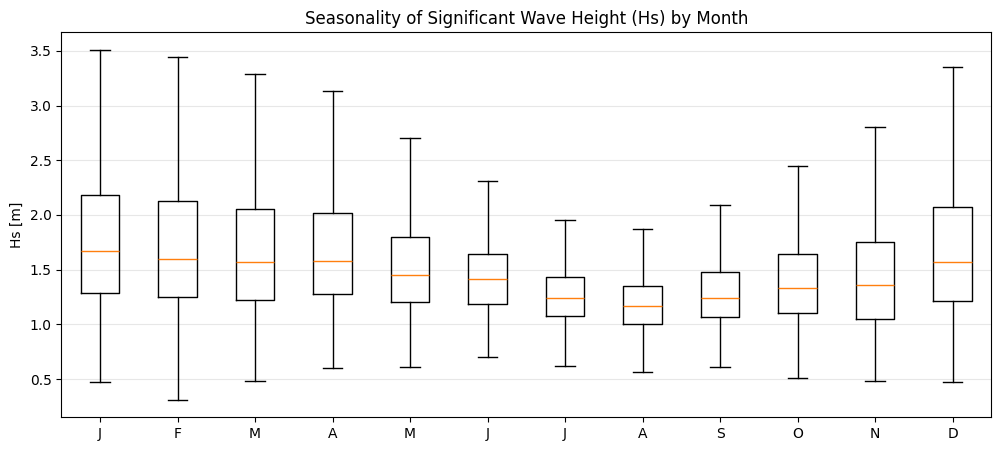

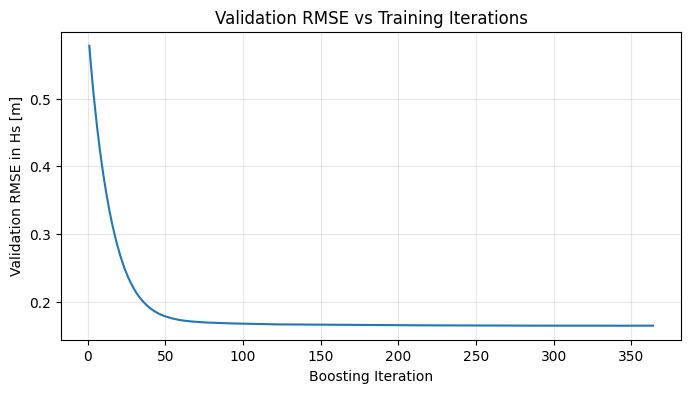

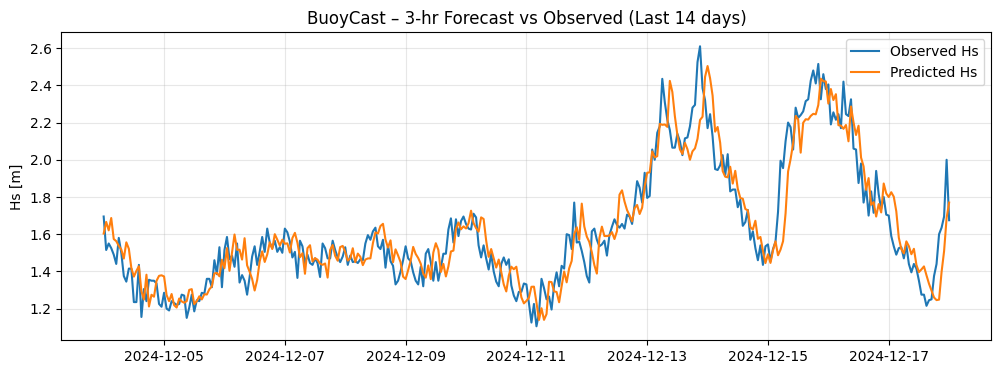

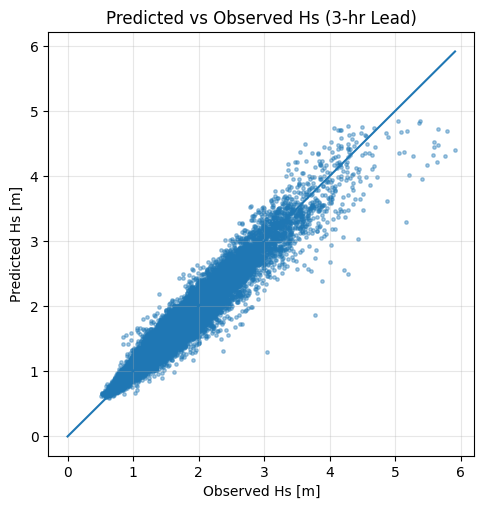

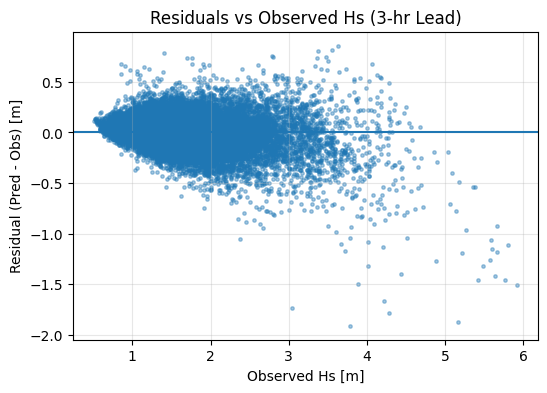

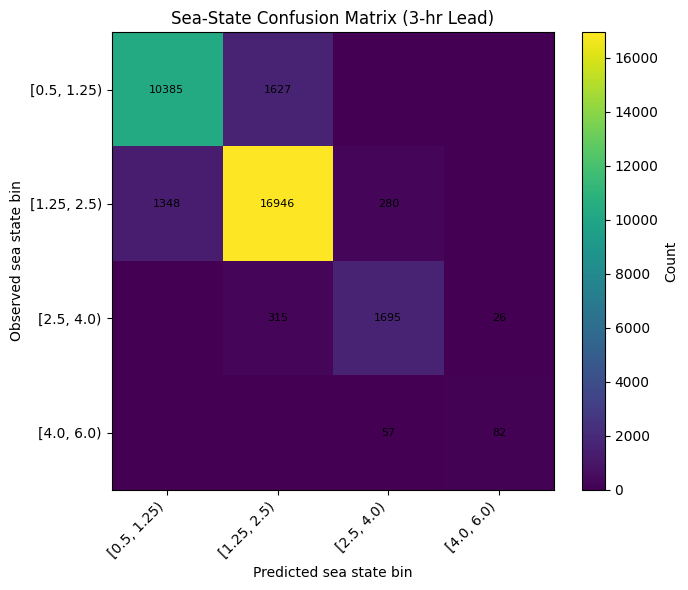

In [8]:
if __name__ == "__main__":

    parquet_path = "./ndbc_parquet/46086/46086_stdmet_clean_all_years.parquet"

    # ---------- Run model comparison ----------
    results = run_global_vs_monthly(
        parquet_path,
        lead_hours=3,
        lags=[0,1,2,3,6,12],
        train_end="2018-12-31",
        val_end="2020-12-31",
    )

    print(results)

    # ---------- Reload data for plots ----------
    df_raw = pd.read_parquet(parquet_path)
    df_feat = prepare_features(df_raw)

    # ---------- DATA VISUALS ----------
    plot_monthly_hs_box(df_feat)

    # ---------- REBUILD supervised data (same as model) ----------
    sup_seasonal = make_supervised(
        df_feat,
        lead_hours=3,
        lags=[0,1,2,3,6,12],
        add_seasonal=True,
    )

    train, val, test = time_split(
        sup_seasonal,
        train_end="2018-12-31",
        val_end="2020-12-31",
    )

    feature_cols = [c for c in sup_seasonal.columns if "_lag" in c]

    # ---------- Refit best model (global + seasonal) ----------
    model = fit_hgbr(train[feature_cols], train["target_E_star"])

    y_pred_test = model.predict(test[feature_cols])
    y_true_test = test["target_E_star"].to_numpy()

    # ---------- MODEL VISUALS ----------
    plot_validation_curve_hgbr(model, val[feature_cols], val["target_E_star"])

    plot_forecast_timeseries(
        test.index,
        y_true_test,
        y_pred_test,
        title="BuoyCast – 3-hr Forecast vs Observed",
        days=14,
    )

    plot_pred_vs_obs(
        y_true_test,
        y_pred_test,
        title="Predicted vs Observed Hs (3-hr Lead)",
    )

    plot_residuals(
        y_true_test,
        y_pred_test,
        title="Residuals vs Observed Hs (3-hr Lead)",
    )

    # ---------- CLASSIFICATION VISUAL ----------
    hs_true = np.sqrt(np.clip(y_true_test, 0, None))
    hs_pred = np.sqrt(np.clip(y_pred_test, 0, None))

    bins = [0, 0.5, 1.25, 2.5, 4.0, 6.0, 9.0, np.inf]

    plot_confusion_matrix(
        hs_true,
        hs_pred,
        bins=bins,
        title="Sea-State Confusion Matrix (3-hr Lead)",
    )
